# 03 — Model Comparison

We now have a validated feature set from notebook 02. This notebook 
asks: which type of model best predicts life expectancy using those features?

We compare four models using the same cross-validation approach throughout:
- Linear Regression (baseline)
- Ridge Regression (handles multicollinearity)
- Random Forest (captures non-linear relationships)
- Gradient Boosting (sequential tree-based, typically strongest)

Models are evaluated on three metrics:
- **R²** — how much variation the model explains (higher is better)
- **RMSE** — average prediction error in years (lower is better)
- **MAE** — average absolute error in years (lower is better)

**Input:** `../data/selected_features.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/selected_features.csv')

feature_cols = [
    'Adult Mortality', 'BMI', 'Polio', 'Diphtheria', 'HIV/AIDS',
    'GDP', 'thinness  1-19 years', 'Income composition of resources',
    'Schooling', 'Status_binary'
]

X = df[feature_cols]
y = df['Life expectancy']

# Scale for linear models — tree models don't need scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", X.shape)
print("Target range:", round(y.min(), 1), "to", round(y.max(), 1), "years")
print("Target mean:", round(y.mean(), 1), "years")

Dataset shape: (2928, 10)
Target range: 36.3 to 89.0 years
Target mean: 69.2 years


In [3]:
# ── RUN ALL FOUR MODELS ───────────────────────────────────────────
# We use 5-fold cross-validation for every model
# This means each model is trained 5 times on different subsets
# and tested on data it has never seen — giving honest performance estimates

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Use scaled data for linear models, raw for tree models
    X_input = X_scaled if name in ['Linear Regression', 'Ridge Regression'] else X
    
    r2_scores = cross_val_score(model, X_input, y, cv=kf, scoring='r2')
    rmse_scores = cross_val_score(model, X_input, y, cv=kf, 
                                   scoring='neg_root_mean_squared_error')
    mae_scores = cross_val_score(model, X_input, y, cv=kf,
                                  scoring='neg_mean_absolute_error')
    
    results.append({
        'Model': name,
        'R²': round(r2_scores.mean(), 4),
        'R² std': round(r2_scores.std(), 4),
        'RMSE': round(-rmse_scores.mean(), 3),
        'RMSE std': round(rmse_scores.std(), 3),
        'MAE': round(-mae_scores.mean(), 3),
        'MAE std': round(mae_scores.std(), 3)
    })
    
    print(f"{name}")
    print(f"  R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  RMSE: {-rmse_scores.mean():.3f} ± {rmse_scores.std():.3f} years")
    print(f"  MAE:  {-mae_scores.mean():.3f} ± {mae_scores.std():.3f} years")
    print()

results_df = pd.DataFrame(results)
print("="*60)
print(results_df[['Model', 'R²', 'RMSE', 'MAE']].to_string(index=False))

Linear Regression
  R²:   0.8086 ± 0.0110
  RMSE: 4.155 ± 0.139 years
  MAE:  3.082 ± 0.107 years

Ridge Regression
  R²:   0.8086 ± 0.0110
  RMSE: 4.155 ± 0.139 years
  MAE:  3.082 ± 0.107 years

Random Forest
  R²:   0.9602 ± 0.0039
  RMSE: 1.894 ± 0.116 years
  MAE:  1.199 ± 0.075 years

Gradient Boosting
  R²:   0.9400 ± 0.0049
  RMSE: 2.326 ± 0.118 years
  MAE:  1.666 ± 0.099 years

            Model     R²  RMSE   MAE
Linear Regression 0.8086 4.155 3.082
 Ridge Regression 0.8086 4.155 3.082
    Random Forest 0.9602 1.894 1.199
Gradient Boosting 0.9400 2.326 1.666


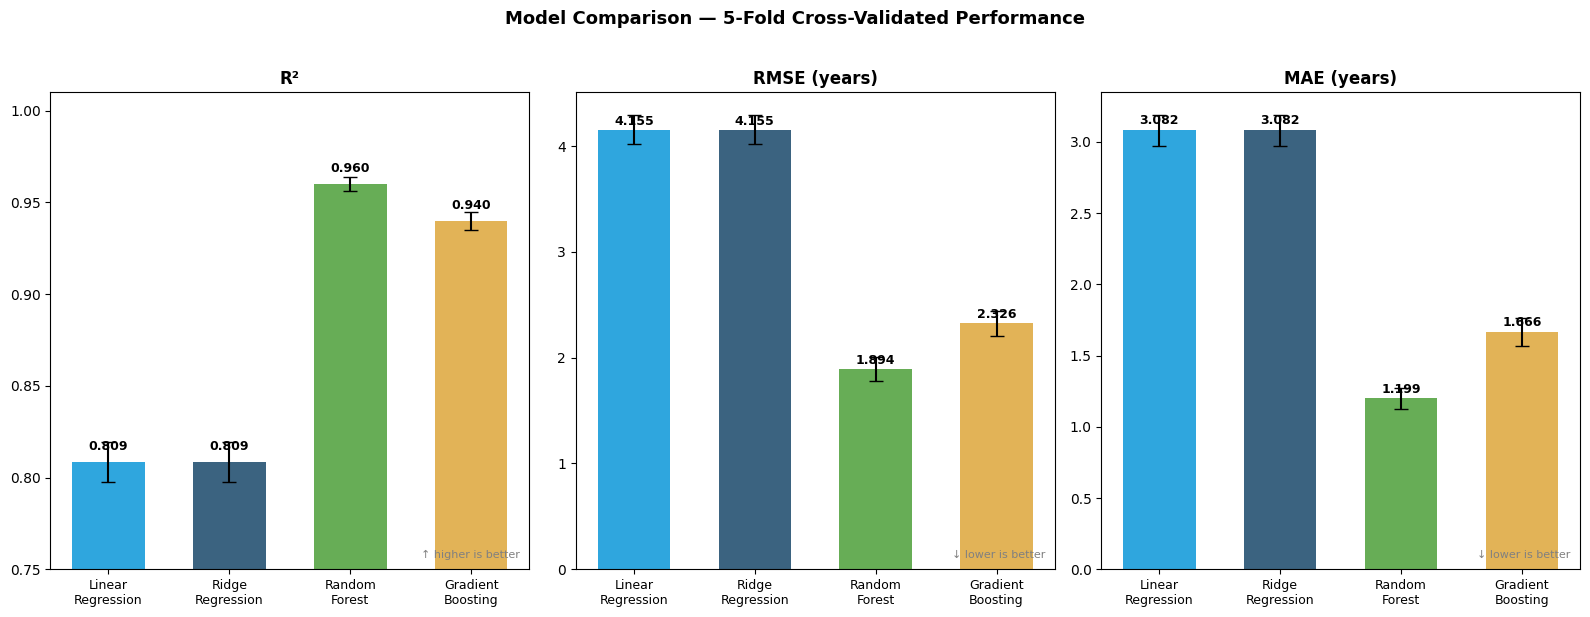

Chart saved
Saved model_comparison_results.csv


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = [
    ('R²', 'R²', True, 0.75),
    ('RMSE', 'RMSE (years)', False, None),
    ('MAE', 'MAE (years)', False, None)
]

colors = ['#0A97D9', '#19486A', '#4C9F38', '#DDA63A']
model_names = results_df['Model'].tolist()

for ax, (metric, label, higher_better, floor) in zip(axes, metrics):
    bars = ax.bar(
        range(len(model_names)),
        results_df[metric],
        color=colors, alpha=0.85,
        width=0.6
    )
    
    # Error bars using std
    std_col = metric + ' std'
    ax.errorbar(
        range(len(model_names)),
        results_df[metric],
        yerr=results_df[std_col],
        fmt='none', color='black',
        capsize=5, linewidth=1.5
    )
    
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(
        [m.replace(' ', '\n') for m in model_names],
        fontsize=9
    )
    
    if floor:
        ax.set_ylim(floor, 1.01)
    
    # Value labels
    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.005 if higher_better else 0.02),
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    
    note = '↑ higher is better' if higher_better else '↓ lower is better'
    ax.text(0.98, 0.02, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='grey')

plt.suptitle('Model Comparison — 5-Fold Cross-Validated Performance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

# Save results
results_df.to_csv('../data/model_comparison_results.csv', index=False)
print("Saved model_comparison_results.csv")

In [5]:
# ── FIT FINAL RANDOM FOREST MODEL ─────────────────────────────────
# Now that we have selected our model we fit it on the full dataset
# and extract feature importance scores.
#
# Feature importance in Random Forest measures how much each variable
# reduces prediction error across all trees on average.
# A variable used frequently at the top of many trees gets a high score.
# A variable rarely used or only used deep in trees gets a low score.

from sklearn.model_selection import train_test_split

# Split into train and test — 80% train, 20% test
# We hold out 20% as a final honest evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit final model
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

# Evaluate on held-out test set
y_pred = rf_final.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print("Final Random Forest — Test Set Performance")
print("="*45)
print(f"R²:   {test_r2:.4f}")
print(f"RMSE: {test_rmse:.3f} years")
print(f"MAE:  {test_mae:.3f} years")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Rankings:")
print(importance_df.to_string(index=False))

Final Random Forest — Test Set Performance
R²:   0.9671
RMSE: 1.687 years
MAE:  1.079 years

Feature Importance Rankings:
                        Feature  Importance
                       HIV/AIDS    0.587578
Income composition of resources    0.198122
                Adult Mortality    0.128575
                            BMI    0.028309
                      Schooling    0.019298
           thinness  1-19 years    0.015808
                            GDP    0.007609
                          Polio    0.007291
                     Diphtheria    0.006758
                  Status_binary    0.000652


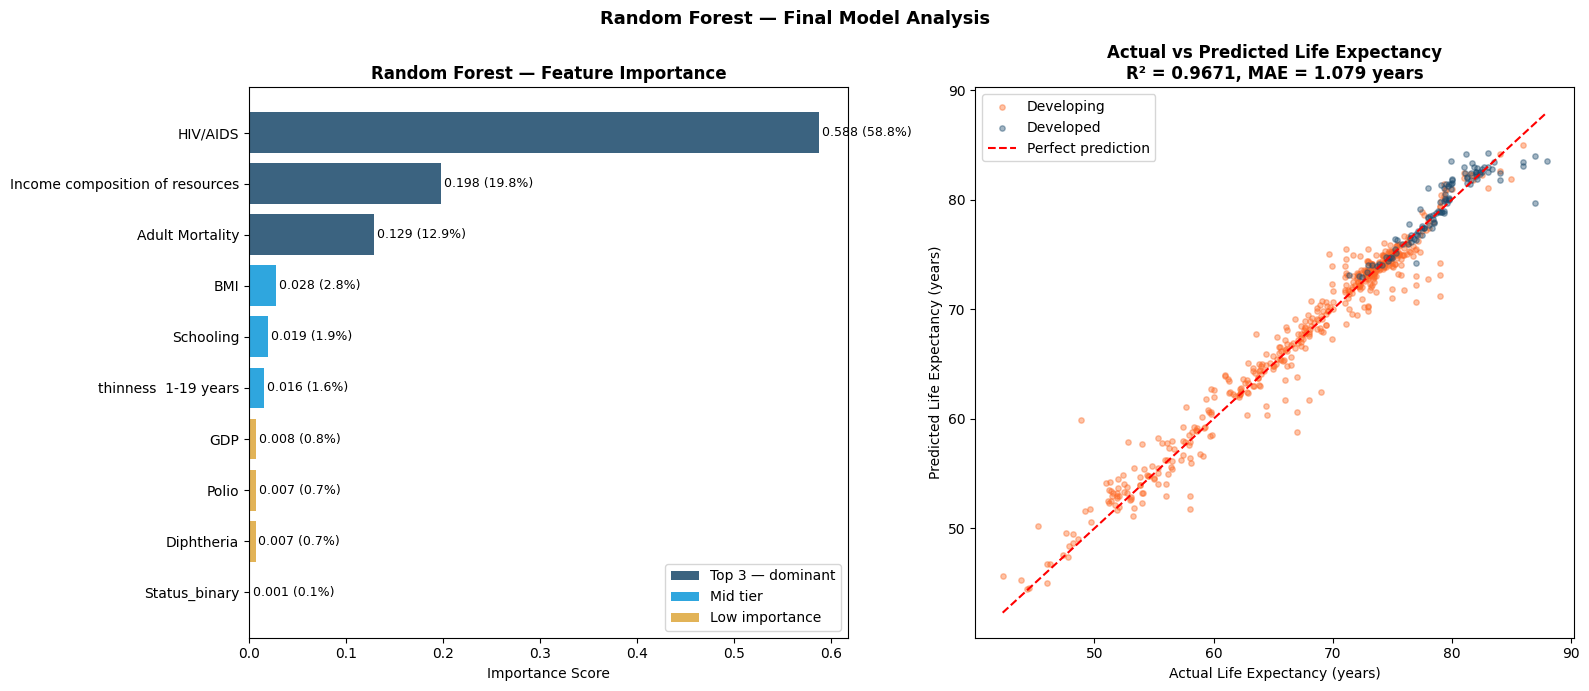

Chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Feature Importance ───────────────────────────────────
colors = ['#19486A' if i < 3 else '#0A97D9' if i < 6 else '#DDA63A' 
          for i in range(len(importance_df))]

bars = axes[0].barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors, alpha=0.85
)
axes[0].set_title('Random Forest — Feature Importance',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

for bar, val in zip(bars, importance_df['Importance']):
    axes[0].text(
        val + 0.003, bar.get_y() + bar.get_height()/2,
        f'{val:.3f} ({val*100:.1f}%)',
        va='center', fontsize=9
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#19486A', alpha=0.85, label='Top 3 — dominant'),
    Patch(facecolor='#0A97D9', alpha=0.85, label='Mid tier'),
    Patch(facecolor='#DDA63A', alpha=0.85, label='Low importance')
]
axes[0].legend(handles=legend_elements, loc='lower right')

# ── Chart 2: Actual vs Predicted ──────────────────────────────────
# This shows where the model gets things right and where it struggles
# Points on the diagonal line = perfect prediction
# Points far from the line = large errors

developing_mask = df.loc[y_test.index, 'Status'] == 'Developing'

axes[1].scatter(
    y_test[developing_mask], y_pred[developing_mask],
    alpha=0.4, s=15, color='#FD6925', label='Developing'
)
axes[1].scatter(
    y_test[~developing_mask], y_pred[~developing_mask],
    alpha=0.4, s=15, color='#19486A', label='Developed'
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect prediction')

axes[1].set_title(f'Actual vs Predicted Life Expectancy\nR² = {test_r2:.4f}, MAE = {test_mae:.3f} years',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Actual Life Expectancy (years)')
axes[1].set_ylabel('Predicted Life Expectancy (years)')
axes[1].legend()

plt.suptitle('Random Forest — Final Model Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_final_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [7]:
# Save final predictions for use in the report notebook
predictions_df = pd.DataFrame({
    'Country': df.loc[y_test.index, 'Country'].values,
    'Year': df.loc[y_test.index, 'Year'].values,
    'Status': df.loc[y_test.index, 'Status'].values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_pred - y_test.values,
    'Abs_Error': np.abs(y_pred - y_test.values)
})

predictions_df = predictions_df.sort_values('Abs_Error', ascending=False)
predictions_df.to_csv('../data/model_predictions.csv', index=False)

importance_df.to_csv('../data/feature_importance.csv', index=False)

print("Saved model_predictions.csv")
print("Saved feature_importance.csv")
print("\nTop 10 largest prediction errors:")
print(predictions_df[['Country', 'Year', 'Actual', 'Predicted', 'Error']].head(10).to_string(index=False))

Saved model_predictions.csv
Saved feature_importance.csv

Top 10 largest prediction errors:
                         Country  Year  Actual  Predicted  Error
                     South Sudan  2000    48.9     59.904 11.004
                        Zimbabwe  2015    67.0     58.830 -8.170
Saint Vincent and the Grenadines  2001    79.0     71.246 -7.754
                       Singapore  2006    87.0     79.688 -7.312
                      Madagascar  2005    69.0     62.405 -6.595
                          Uganda  2013    67.0     60.596 -6.404
                      Kyrgyzstan  2013    77.0     70.689 -6.311
                          Gambia  2014    68.0     61.714 -6.286
     United Republic of Tanzania  2003    58.0     51.801 -6.199
                         Grenada  2002    79.0     73.151 -5.849
